# Исследование стартапов

Финансовая компания, работающая с венчурными инвестициями, хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний. Для этого необходимо провести исследование на исторических данных.

## Цели и задачи

**Цель:** Провести исследование динамики и структуры финансирования стартапов для оценки перспектив выхода на рынок с покупкой и развитием компаний.   

**Задачи:**
1. [Загрузить данные и провести их предобработку](#link1)
2. [Провести инжиниринг признаков](#link2)
3. [Провести работу с выбросами и анализ](#link3)
4. [Выполнить анализ динамики](#link4)
4. [Сформулировать выводы по проведённому анализу](#link5)

<a class='anchor' id="link1"></a>
## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### 1.1. Вывод общей информации

Загрузим необходимые для работы библиотеки.

In [1]:
# Установим библиотеки missingno
!pip install missingno -q

In [2]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

Загрузим все данные по проекту.

In [4]:
# Выгружаем данные в переменные df и df_returns
df = pd.read_csv('cb_investments.zip', sep=';', low_memory=False)
df_returns = pd.read_csv('cb_returns.csv')

Выведем информацию, которая необходима для принятия решений о предобработке.

In [5]:
# Выводим первые строки датафрейма cb_investments.csv на экран
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.00,NaN,1636-09-08,NaN,NaN,1636.00,2014-01-06,NaN,2014-01-06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,90000000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.00,NaN,1785-01-01,NaN,NaN,1785.00,2014-05-15,NaN,2014-05-15,0.00,2000000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.00,1.00,1802-07-19,NaN,NaN,1802.00,2009-07-02,2009-07-02,2009-07-02,0.00,9000000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.00,0.00,1817-01-01,NaN,NaN,1817.00,2013-11-21,2013-11-21,2014-11-03,0.00,0.00,0.00,1600000.00,0.00,0.00,0.00,6100000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.00,NaN,1826-01-01,NaN,NaN,1826.00,2014-01-14,NaN,2014-01-14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,540000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [6]:
# Выводим информацию о датафрейме cb_investments.csv
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [7]:
# Статистики для столбцов типа 'object'
df.describe(include=['object'])

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,founded_at,founded_month,founded_quarter,first_funding_at,mid_funding_at,last_funding_at
count,49437,45989,45477,45477,49438,48124,44165,30161,44165,43322,38554,38482,38482,49438,30288,49438
unique,49350,45850,16675,939,14617,3,115,61,1089,4188,3369,420,218,3914,3106,3657
top,Spire,http://getjobber.com,|Software|,Software,-,operating,USA,CA,SF Bay Area,San Francisco,2012-01-01,2012-01,2012-Q1,2012-01-01,2008-01-01,2013-01-01
freq,4,2,3650,4781,8531,41829,28793,9917,6804,2615,2181,2327,2904,468,326,387


In [8]:
# Из 54294 строк датасета в 4857 заполнено значение name. Проверим заполнение остальных стобцов для этих 4857 строк.
df[df['name'].isna() == True].isna().sum()

name                    4857
homepage_url            4856
category_list           4856
 market                 4856
 funding_total_usd      4856
status                  4856
country_code            4857
state_code              4857
region                  4857
city                    4857
funding_rounds          4856
participants            4857
founded_at              4856
founded_month           4856
founded_quarter         4856
founded_year            4856
first_funding_at        4856
mid_funding_at          4857
last_funding_at         4856
seed                    4856
venture                 4856
equity_crowdfunding     4856
undisclosed             4856
convertible_note        4856
debt_financing          4856
angel                   4856
grant                   4856
private_equity          4856
post_ipo_equity         4856
post_ipo_debt           4856
secondary_market        4856
product_crowdfunding    4856
round_A                 4856
round_B                 4856
round_C       

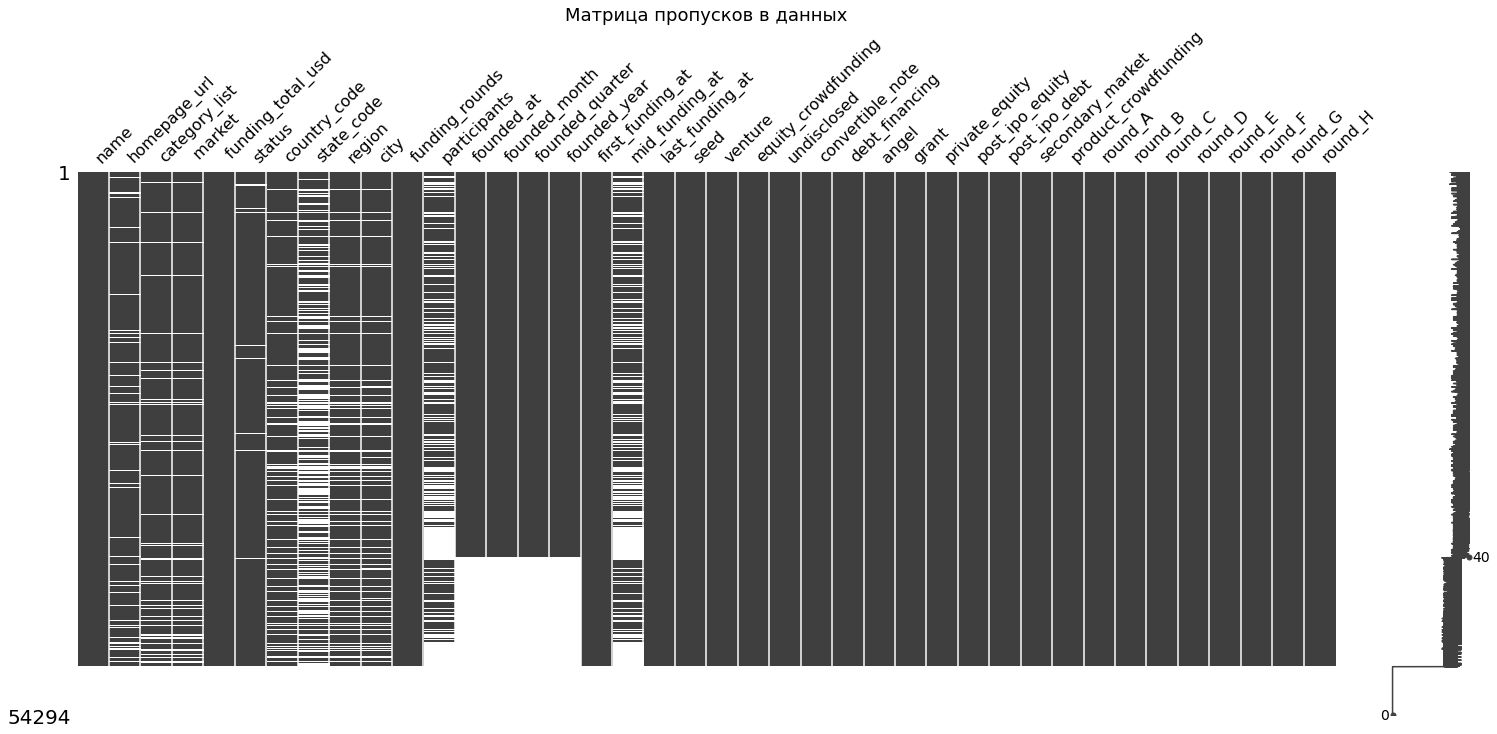

In [9]:
# Построим матрицу missingno для визуализации пропусков
msno.matrix(df)
plt.title('Матрица пропусков в данных', fontsize=18)
plt.show()

In [10]:
# Выводим первые строки датафрейма cb_returns.csv на экран
df_returns.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.00,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.00,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.00,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.00,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.00,2.19,3.38,0.00,0.55,0.00


In [11]:
# Выводим информацию о датафрейме cb_returns.csv
df_returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [12]:
# Статистики для числовых столбцов
df_returns.describe().round(2)

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
count,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00,15.00
mean,2007.00,158.82,2705.24,0.26,48.73,2.32,315.66,100.62,0.00,239.16,73.66,6.07,0.35,0.12
std,4.47,180.02,2206.93,0.39,27.83,2.50,345.37,95.50,0.00,324.39,86.99,12.48,0.30,0.21
min,2000.00,2.88,23.49,0.00,9.40,0.00,1.09,1.18,0.00,0.00,0.34,0.00,0.05,0.00
25%,2003.50,13.32,394.88,0.00,29.48,0.02,11.10,7.80,0.00,1.90,2.74,0.00,0.12,0.00
50%,2007.00,70.41,2717.02,0.03,46.74,1.78,125.68,97.21,0.00,88.81,24.36,0.00,0.20,0.00
75%,2010.50,291.31,3752.38,0.34,65.20,3.59,538.33,168.34,0.00,361.54,122.36,1.52,0.51,0.25
max,2014.00,530.75,7272.01,1.15,105.72,7.87,1017.75,293.98,0.00,988.53,262.70,37.20,1.03,0.72


#### Промежуточный вывод

Датасет **cb_investments.csv** содержит 40 столбцов и 54294 строк, в которых представлена информация о компаниях и состоявшемся финансировании.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов корректны, но часть столбцов содержат лишние пробелы в названиях, которые следует удалить. Названия столбцов с суммами инвестиций в соответствующих раундах можно привести к нижнему регистру.
- 24 столбца имеют тип данных `float64`:
    - 21 столбец содержит сведения о различных суммах, тип `float64` подходит для этих данных (`seed, venture, equity_crowdfunding, undisclosed, convertible_note, debt_financing, angel, grant, private_equity, post_ipo_equity, post_ipo_debt, secondary_market, product_crowdfunding, round_A — round_H`), но размерность этих данных можно оптимизировать;
    - столбцы `funding_rounds, participants, founded_year` содержат сведения об общем числе раундов финансирования, числе участников в раундах финансирования, годе основания; для этих данных больше подходит целочисленный  тип.
- 16 столбцов имет тип данных `object`:
    - 9 столбцов содержат строковую информацию (`name, homepage_url, category_list, market, status, country_code, state_code, region, city`), для этих значений тип данных `object` подходит;
    - столбец `funding_total_usd` содержит информацию об общем объёме привлечённых инвестиций, необходимо привести его к типу `float32`;
    - 6 столбцов содержат информацию о датах (`founded_at, founded_month, founded_quarter, first_funding_at, mid_funding_at, last_funding_at`), для этих данных больше подходит тип `datetime64`.
- Пропуски содержатся во всех столбцах. В датасете содержится 4856 строк, состоящих из пропусков во всех столбцах, их необходимо удалить.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Датасет **`cb_returns.csv`** содержит 14 столбцов и 15 строк, в которых представлена информация об объёмах возвратов по годам и типам финансирования в миллионах долларов.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов корректны и приведены к стилю snake case.
- Столбец `year` имеет тип `int64` и содержит сведения о годах возврата средств, этот столбец нужно сделать индексом всего датасета.
- Остальные столбцы имеют тип `float64`, содержат информацию о различных суммах; тип `float64` подходит для этих данных, но размерность этих данных можно оптимизировать.
- Пропуски в датасете отсутствуют.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

### 1.2. Предобработка данных

Проверим названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле.

In [13]:
# Удалим лишние пробелы в начале и конце названий и приведем к нижнему регистру
df.columns = df.columns.str.lower().str.strip()
df.columns

Index(['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd',
       'status', 'country_code', 'state_code', 'region', 'city',
       'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_a', 'round_b',
       'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h'],
      dtype='object')

In [14]:
# Подсчитаем количество строк в исходном датафрейме
init_row_count = df.shape[0]
init_row_count

54294

In [15]:
#Удалим строки, где все значения - NaN
df = df.dropna(how='all')
df.shape[0]

49438

Уберем в столбце `funding_total_usd` выделение разрядов и приведем его к числовому типу.

In [16]:
df['funding_total_usd'] = df['funding_total_usd'].str.replace(',', '')
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], downcast='float', errors='coerce')

Обработаем типы данных в столбцах, которые хранят значения даты и времени.

In [17]:
for column in ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']:
    df[column] = pd.to_datetime(df[column], format='%Y-%m-%d', errors='coerce')
df['founded_month'] = pd.to_datetime(df['founded_month'], format='%Y-%m', errors='coerce')
df['founded_quarter'] = pd.to_datetime(df['founded_month'], format='%Y-Q%q', errors='coerce')

Для оптимизации работы с данными в датафрейме выполним изменения типов данных.

In [18]:
# Преобразуем тип float64 в int8 для funding_rounds
df['funding_rounds'] = pd.to_numeric(df['funding_rounds'], downcast='integer')

In [19]:
# Преобразуем тип float64 в целочисленный для столбцов participants, founded_year (Int64, т.к. есть пропуски)
for column in ['participants', 'founded_year']:
    df[column] = df[column].astype('Int64')

In [20]:
# Понизим разрядность для столбцов с float64 до float32
float_cols = df.select_dtypes(include=['float64']).columns
for col in float_cols:
    df[col] = pd.to_numeric(df[col], downcast='float')

In [21]:
# Преобразуем тип status в category
df['status'] = df['status'].astype('category')

In [22]:
# Проверим типы данных после всех преобразований в датафрейме df
df.dtypes

name                            object
homepage_url                    object
category_list                   object
market                          object
funding_total_usd              float32
status                        category
country_code                    object
state_code                      object
region                          object
city                            object
funding_rounds                    int8
participants                     Int64
founded_at              datetime64[ns]
founded_month           datetime64[ns]
founded_quarter         datetime64[ns]
founded_year                     Int64
first_funding_at        datetime64[ns]
mid_funding_at          datetime64[ns]
last_funding_at         datetime64[ns]
seed                           float32
venture                        float32
equity_crowdfunding            float32
undisclosed                    float32
convertible_note               float32
debt_financing                 float32
angel                    

In [23]:
# В датафрейме df_returns понизим разрядность для столбцов с float64 до float32
float_cols = df_returns.select_dtypes(include=['float64']).columns
for col in float_cols:
    df_returns[col] = pd.to_numeric(df_returns[col], downcast='float')

In [24]:
# Проверим типы данных после всех преобразований в датафрейме df
df_returns.dtypes

year                      int64
seed                    float32
venture                 float32
equity_crowdfunding     float32
undisclosed             float32
convertible_note        float32
debt_financing          float32
angel                   float32
grant                   float32
private_equity          float32
post_ipo_equity         float32
post_ipo_debt           float32
secondary_market        float32
product_crowdfunding    float32
dtype: object

В датасете `cb_returns` сделаем столбец `year` индексом всего датасета.

In [25]:
df_returns = df_returns.set_index('year')

Обработаем текстовые данные.

In [26]:
# Выводим количество пропущенных строк в датафрейме
df.isna().sum().sort_values()

seed                        0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
equity_crowdfunding         0
post_ipo_debt               0
product_crowdfunding        0
round_a                     0
round_b                     0
round_c                     0
round_d                     0
round_e                     0
round_f                     0
secondary_market            0
venture                     0
round_h                     0
round_g                     0
funding_rounds              0
name                        1
last_funding_at             6
first_funding_at           10
status                   1314
homepage_url             3449
market                   3961
category_list            3961
region                   5273
country_code             5273
city                     6116
funding_total_usd        8531
founded_ye

In [27]:
# Подсчитаем процент строк с пропусками
df.isna().sum().sort_values() / len(df) * 100

seed                    0.00
undisclosed             0.00
convertible_note        0.00
debt_financing          0.00
angel                   0.00
grant                   0.00
private_equity          0.00
post_ipo_equity         0.00
equity_crowdfunding     0.00
post_ipo_debt           0.00
product_crowdfunding    0.00
round_a                 0.00
round_b                 0.00
round_c                 0.00
round_d                 0.00
round_e                 0.00
round_f                 0.00
secondary_market        0.00
venture                 0.00
round_h                 0.00
round_g                 0.00
funding_rounds          0.00
name                    0.00
last_funding_at         0.01
first_funding_at        0.02
status                  2.66
homepage_url            6.98
market                  8.01
category_list           8.01
region                 10.67
country_code           10.67
city                   12.37
funding_total_usd      17.26
founded_year           22.02
founded_at    

In [28]:
# Проверяем уникальные значения
for column in ['market', 'status', 'country_code', 'state_code']:
    print(f'Уникальные значения в столбце {column}:')
    print(df[column].sort_values().unique())
    print()

Уникальные значения в столбце market:
[' 3D' ' 3D ' ' 3D Printing ' ' 3D Technology ' ' Ad Targeting '
 ' Advanced Materials ' ' Adventure Travel ' ' Advertising'
 ' Advertising ' ' Advertising  ' ' Advertising Networks '
 ' Advertising Platforms ' ' Advice ' ' Aerospace ' ' Agriculture '
 ' Algorithms ' ' All Students ' ' Alternative Medicine ' ' Analytics'
 ' Analytics ' ' Analytics  ' ' Android' ' Android ' ' Animal Feed '
 ' App Marketing ' ' App Marketing  ' ' App Stores '
 ' Application Platforms ' ' Apps' ' Apps ' ' Apps  ' ' Art '
 ' Artificial Intelligence' ' Artificial Intelligence '
 ' Artists Globally ' ' Assisitive Technology ' ' Auctions ' ' Audio '
 ' Augmented Reality ' ' Automotive' ' Automotive ' ' Automotive  '
 ' B2B ' ' Baby Accessories ' ' Banking ' ' Batteries ' ' Beauty '
 ' Bicycles ' ' Big Data' ' Big Data ' ' Big Data Analytics'
 ' Big Data Analytics ' ' Biotechnology' ' Biotechnology '
 ' Biotechnology  ' ' Bitcoin ' ' Blogging Platforms ' ' Brand Marketing'

In [29]:
# Удалим лишние пробелы в начале и конце названия основного рынка и приведем наименование к нижнему регистру
df['market'] = df['market'].str.strip().str.lower()
# Удалим лишние пробелы в начале и конце названия компании
df['name'] = df['name'].str.strip()

Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. Избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [30]:
# Проверяем полные дубликаты в датафрейме df
df.duplicated().sum()

0

In [31]:
# Проверяем полные дубликаты в датафрейме df_returns
df_returns.duplicated().sum()

0

In [32]:
# Удалим все строки с пропусками в столбце funding_total_usd
df = df.dropna(subset=['funding_total_usd'])

Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.

Оценим размер оставшихся пропусков в столбце.

In [33]:
mid_funding = df['first_funding_at'] + (df['last_funding_at'] - df['first_funding_at']) / 2
df['mid_funding_at'] = df['mid_funding_at'].fillna(mid_funding)

In [34]:
df['mid_funding_at'].isna().sum()

1

In [35]:
# Удалим 1 строку с пропуском в столбце mid_funding_at
df = df.dropna(subset=['mid_funding_at'])

Оценим полноту данных и сделаем предварительный вывод о том, достаточно ли данных для решения задач проекта.

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40906 entries, 0 to 49437
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40905 non-null  object        
 1   homepage_url          38592 non-null  object        
 2   category_list         38403 non-null  object        
 3   market                38403 non-null  object        
 4   funding_total_usd     40906 non-null  float32       
 5   status                39801 non-null  category      
 6   country_code          37087 non-null  object        
 7   state_code            25619 non-null  object        
 8   region                37087 non-null  object        
 9   city                  36401 non-null  object        
 10  funding_rounds        40906 non-null  int8          
 11  participants          27331 non-null  Int64         
 12  founded_at            32199 non-null  datetime64[ns]
 13  founded_month   

In [37]:
# Подсчитаем процент строк с пропусками
df.isna().sum().sort_values() / len(df) * 100

seed                    0.00
undisclosed             0.00
convertible_note        0.00
debt_financing          0.00
angel                   0.00
grant                   0.00
private_equity          0.00
post_ipo_equity         0.00
equity_crowdfunding     0.00
post_ipo_debt           0.00
product_crowdfunding    0.00
round_a                 0.00
round_b                 0.00
round_c                 0.00
round_d                 0.00
round_e                 0.00
round_f                 0.00
secondary_market        0.00
venture                 0.00
round_h                 0.00
last_funding_at         0.00
mid_funding_at          0.00
funding_total_usd       0.00
round_g                 0.00
funding_rounds          0.00
name                    0.00
first_funding_at        0.00
status                  2.70
homepage_url            5.66
market                  6.12
category_list           6.12
region                  9.34
country_code            9.34
city                   11.01
founded_year  

In [38]:
# Подсчитаем число строк в датафрейме после удаления строк и количество удаленных строк
fin_row_count = df.shape[0]
del_row_count = init_row_count - fin_row_count
del_row_count

13388

In [39]:
# Процент удаленных строк
round(del_row_count / init_row_count * 100, 2)

24.66

#### Промежуточный вывод

В результате предобработки данных в датасете **`cb_investments`** были выполнены следующие действия:
- Для оптимизации работы с данными были произведены следующие изменения типов данных:
    - `funding_total_usd`: после удаления разделителей разрядов тип данных изменен с `object` на `float32`;
    - `founded_at, founded_month, founded_quarter, first_funding_at, mid_funding_at, last_funding_at`: тип данных изменен с `object` на `datetime64`;
    - `status`: с учетом малого количества уникальных значений в столбце (3) тип данных изменен с `object` на `category`;
    - `funding_rounds`, `participants`, `founded_year`: типы данных изменены с `float64` на целочисленные типы (`int8` для `funding_rounds` и `Int64` для `participants`, `founded_year` из-за наличия пропусков в этих столбцах);
    - для столбцов с типом данных `float64` понижена разрядность до `float32`.
- Заполнены пропуски в значениях `mid_funding_at` приблизительной серединой интервала между `first_funding_at` и `last_funding_at`, после чего осталась 1 строка с пропуском в `mid_funding_at` (из-за пропуска в `first_funding_at`), которая была удалена.
- Удалены строки, содержащие пропуски значений во всех столбцах. Также удалены строки с пропусками в столбце `funding_total_usd`, так как они не содержат данных о финансировании и не нужны в дальнейшем анализе.
- После удаления строк пропуски остались в 13 столбцах. Пропуски в этих столбцах по предварительной оценке не влияют на дальнейшее иследование, поэтому такие строки оставлены как есть.
- Данные проверены на явные дубликаты — они отсутствуют.
- Всего в процессе предобработки данных было удалено 13387 строк, что составляет 24.66% от исходного количества. В датасете осталось 40907 строк, этого достаточно для дальнейшего анализа.

В результате предобработки данных датасете **`cb_returns`** были выполнены следующие действия:
- Для столбцов с типом данных `float64` понижена разрядность до `float32`.
- Столбец `year` сделан индексом датасета.
- Пропуски и явные дубликаты отсутствуют.

<a class='anchor' id="link2"></a>
## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: какую долю от общего объёма привлечённых средств получила каждая группа.

In [40]:
# Определяем функцию, которая создаст новый столбец с группой по срокам финансирования
def categorize_funding(row):
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif row['last_funding_at'] - row['first_funding_at'] <= pd.to_timedelta('365 days'):
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

df['category_funding'] = df.apply(categorize_funding, axis=1).astype("category")

In [41]:
plt.style.use('default')

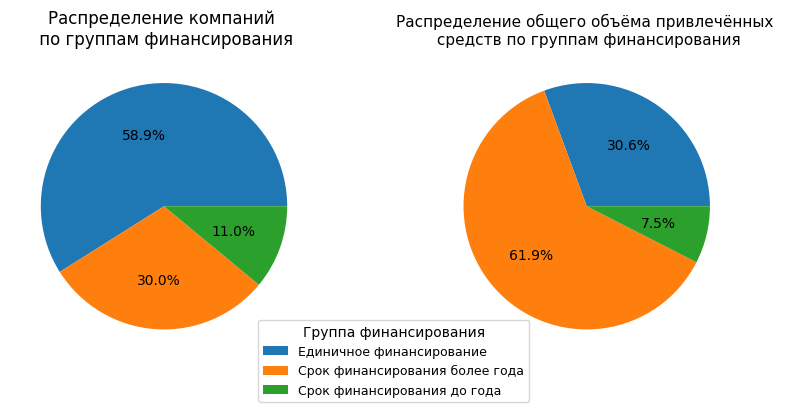

In [42]:
company_category = df['category_funding'].value_counts()
total_sum_category = df.groupby('category_funding')['funding_total_usd'].sum() * 100 / df['funding_total_usd'].sum()

category_labels = ['Единичное финансирование', 'Срок финансирования более года', 'Срок финансирования до года']

# Создание фигуры и осей (1 строка, 2 столбца)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Построение первой круговой диаграммы
ax1.pie(company_category,
        autopct='%1.1f%%')
ax1.set_title('Распределение компаний \n по группам финансирования')

# Построение второй круговой диаграммы
ax2.pie(total_sum_category,
        autopct='%1.1f%%')
ax2.set_title('Распределение общего объёма привлечённых \n средств по группам финансирования', fontsize=11)

# Создание общей легенды
fig.legend(category_labels, loc='lower center', title='Группа финансирования', fontsize=9)

# Выводим график
plt.show()

Большинство компаний (58.9%) участвуют в единичном финансировании, их доля средств составляет 30.6% общего объема инвестиций. Наибольшая доля общего объёма привлечённых средств приходится на финансирование со сроком более 1 года - 61.9%, это 30.1% компаний.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым; сегменты, в которые входит от 35 до 120 включительно, отнесем к средним; а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

In [43]:
# Создадим датафрейм без пропусков в столбце market
df_filtered = df.dropna(subset=['market']).copy()

# Проверяем распределение данных по значениям столбца market
print('Распределение компаний по значениям столбца market:')
df_filtered['market'].value_counts()

Распределение компаний по значениям столбца market:


software                          4812
biotechnology                     3590
mobile                            2344
e-commerce                        1866
curated web                       1693
                                  ... 
unmanned air systems                 1
incubators                           1
coffee                               1
embedded hardware and software       1
logistics company                    1
Name: market, Length: 394, dtype: int64

In [44]:
# Считаем общее количество в каждом сегменте
df_filtered['market_count'] = df_filtered.groupby('market')['market'].transform('count')
# Выполним сегментацию по количеству компаний в каждом сегменте
df_filtered['market_segment'] = pd.cut(df_filtered['market_count'], bins=[0,35,120,float('inf')], labels=['Нишевый', 'Средний', 'Массовый'])

In [45]:
# Проверяем, сколько сегментов попадает в каждую из групп
print('Распределение сегментов компаний по группам:')
df_filtered.groupby('market_segment')['market'].nunique()

Распределение сегментов компаний по группам:


market_segment
Нишевый     289
Средний      57
Массовый     48
Name: market, dtype: int64

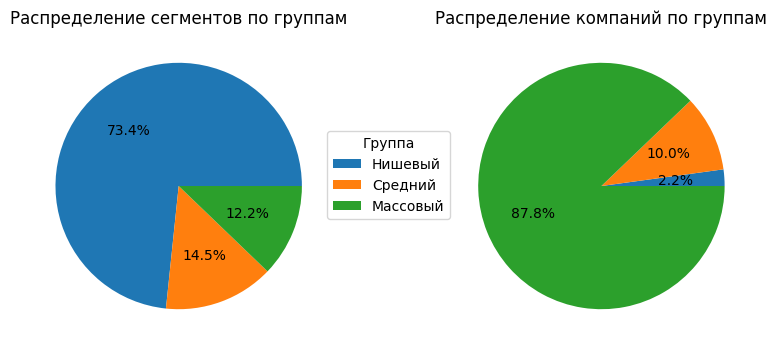

In [46]:
# Посчитаем график с долей сегментов по группам и долей компаний по группам
market_count = df_filtered.groupby('market_segment')['market'].nunique()
company_count = df_filtered.groupby('market_segment')['name'].count()

segment_labels = market_count.index.to_list()

# Создание фигуры и осей (1 строка, 2 столбца)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Построение первой круговой диаграммы
ax1.pie(market_count,
        autopct='%1.1f%%',
        normalize=True)
ax1.set_title('Распределение сегментов по группам')

# Построение второй круговой диаграммы
ax2.pie(company_count,
        autopct='%1.1f%%',
        normalize=True)
ax2.set_title('Распределение компаний по группам')

# Создание общей легенды
fig.legend(segment_labels, loc='center', title='Группа')

# Выводим график
plt.show()

В группе массовых сегментов наблюдается высокая конкуренция: 87.8% компаний в 12.2% сегментов. В нишевой группе сегментов обратная ситуация: большая доля сегментов (73.3%) и очень низкое количество компаний (2.2%). В средней группе сегментов конкуренция умеренная: 10% компаний в 14.5% сегментов. Можно предположить, что массовые сегменты привлекают больше инвестиций из-за понятности их продуктов для инвесторов, предсказуемости и прозрачности рисков. Для нишевых сегментов наоборот: уникальность продукта или идеи отпугивает инвесторов, но потенциально может принести гораздо большую прибыль по сравнению с массовыми сегментами. 

---

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования будем выполнять с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.

In [47]:
mask = (df_filtered['market_segment'] == 'Средний')
df_filtered.loc[mask, 'market'] = 'mid'
mask = (df_filtered['market_segment'] == 'Нишевый')
df_filtered.loc[mask, 'market'] = 'niche'

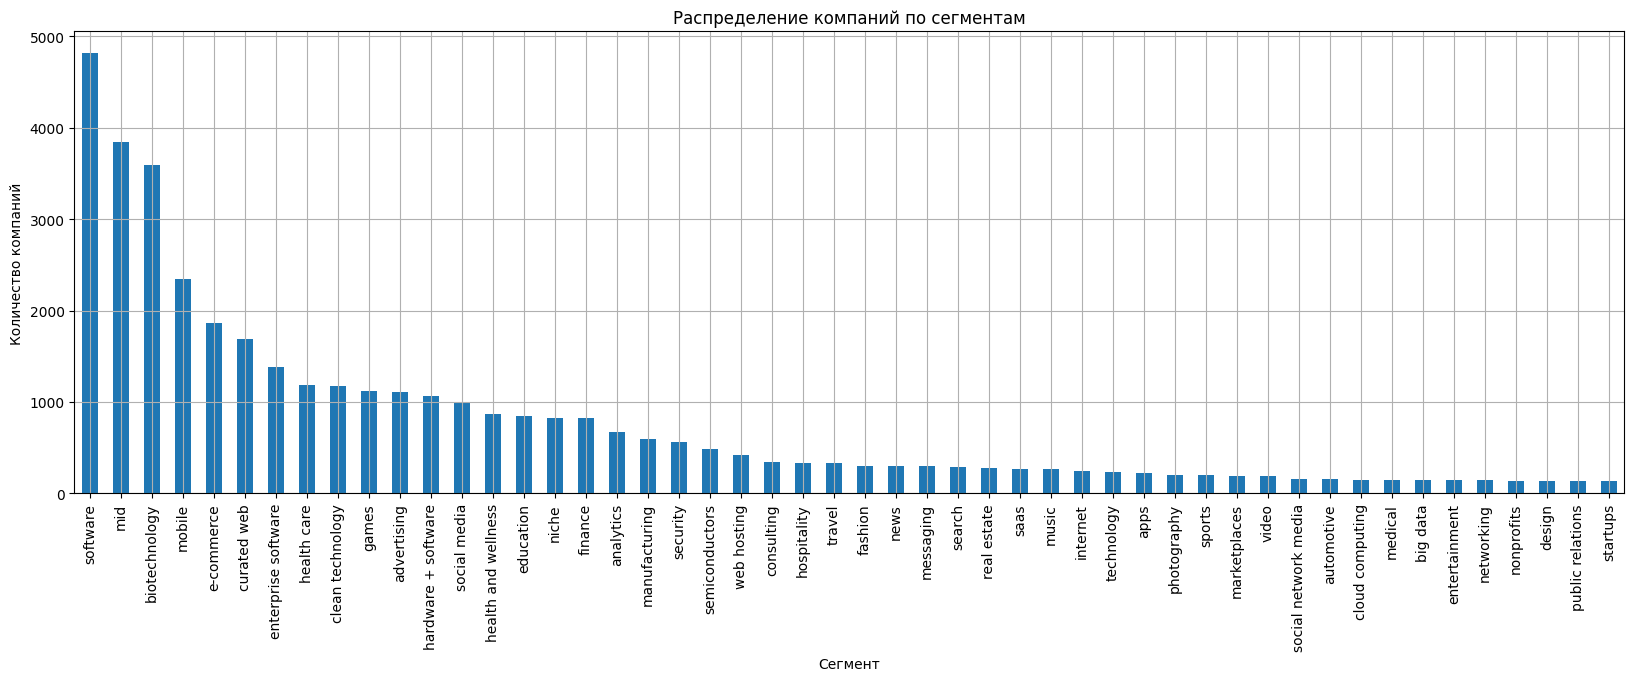

In [48]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(20, 6))

# Строим столбчатую диаграмму
market_count = df_filtered['market'].value_counts().sort_values(ascending=False)
market_count.plot(
               kind='bar',
               rot=90,
               legend=False,
               title=f'Распределение компаний по сегментам'
)

# Настраиваем оформление графика
plt.xlabel('Сегмент')
plt.ylabel('Количество компаний')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Большинство компаний относятся к сегменту `software` из массовой группы - около 4800. Следующая по численности - `средняя группа` сегментов, к ней относится около 3800 компаний. Далее по убыванию популярности - сегменты `biotechnology`, `mobile` и `e-commerce` из массовой группы. Количество компаний, относящихся к нишевой группе сегментов, составляет около 800.

---

### Промежуточный вывод

- В единичном финансировании участвует 58.9% компаний с общей долей инвестиций 30.6%. 
- На финансирование со сроком более 1 года приходится 61.9% привлечённых средств и 30.1% компаний.
- Группа массовых сегментов, к которым относится более 120 компаний, включает 48 различных отраслей рынка, средняя группа сегментов (от 35 до 120 компаний), включает 48 отраслей, а нишевая группа (до 35 компаний) - 289 отраслей. Для дальнейшего анализа сегменты средней и нишевой группы укрупнены, детализация оставлена только для массовой категории сегментов.
- Доля компаний, занятых в массовых сегментах, составляет 87.8%, в нишевых - 2.2%. При этом в нишевых сегментах сосредоточено 73.3% отраслей рынка, тогда как в массовых - 12.2%. На основе этого можно сделать вывод о гиперконкуренции в массовых сегментах и недоосвоенности нишевых сегментов. Средние сегменты отличаются умеренной конкуренцией.
- Наиболее популярные массовые отрасли - `software`, `biotechnology`, `mobile` и `e-commerce`.


<a class='anchor' id="link3"></a>
## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажем интервал, в котором лежат типичные значения.

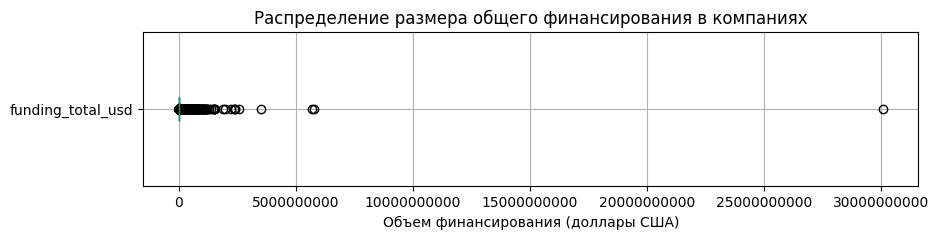

In [49]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 2))

# Строим диаграмму размаха значений в столбце funding_total_usd
df_filtered.boxplot(column='funding_total_usd', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение размера общего финансирования в компаниях')
plt.xlabel('Объем финансирования (доллары США)')
plt.ticklabel_format(style='plain', axis='x')

# Выводим график
plt.show()

Выбросов много и они расположены очень далеко от «усов», что мешает оценить основную часть данных, поэтому построим диаграмму размаха с отключенным отображением выбросов.

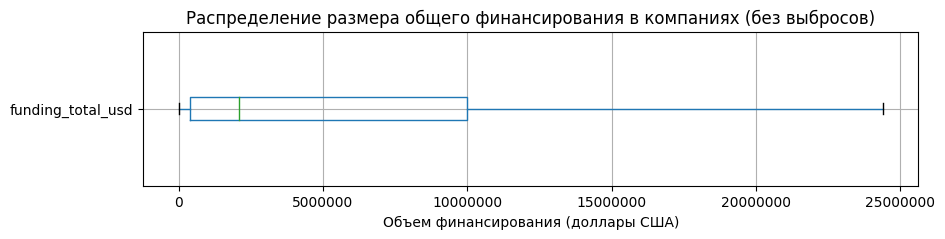

In [50]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 2))

# Строим диаграмму размаха значений в столбце funding_total_usd
df_filtered.boxplot(column='funding_total_usd', vert=False, showfliers=False)

# Добавляем заголовок и метки оси
plt.title('Распределение размера общего финансирования в компаниях (без выбросов)')
plt.xlabel('Объем финансирования (доллары США)')
plt.ticklabel_format(style='plain', axis='x')

# Выводим график
plt.show()

Распределение размера общего финансирования в компаниях асимметричное, скошенное вправо, со значительным числом выбросов. Медианное значение размера общего финансирования составляет 2.1 млн. долларов США. По диаграмме размаха видно, что значения выше примерно 24 млн. долларов США можно считать выбросами. Типичные значения размера общего финансирования находятся в интервале от 0.4 млн. до 10 млн. долларов США.

---

Определим компании с аномальным объёмом общего финансирования, используя метод IQR отдельно по каждому сегменту.

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [51]:
# Отфильтруем данные по объему общего финансирования за пределами "ящика с усами" для каждого значения market
def iqr_filter(group):
    q1 = group['funding_total_usd'].quantile(0.25)
    q3 = group['funding_total_usd'].quantile(0.75)
    iqr = q3 - q1
    return group[(group['funding_total_usd'] < (q1 - 1.5 * iqr)) | (group['funding_total_usd'] > (q3 + 1.5 * iqr))]

df_iqr_out = df_filtered.groupby('market', group_keys=False).apply(iqr_filter)

In [52]:
# Определим топ-10 сегментов рынка с аномальным финансированием
print('Топ-10 сегментов рынка с аномальным финансированием:')
top_market = df_iqr_out['market'].value_counts(normalize=True).head(10)
top_market

Топ-10 сегментов рынка с аномальным финансированием:


software              0.12
mid                   0.11
biotechnology         0.08
mobile                0.06
e-commerce            0.06
curated web           0.04
clean technology      0.03
enterprise software   0.03
social media          0.03
advertising           0.03
Name: market, dtype: float64

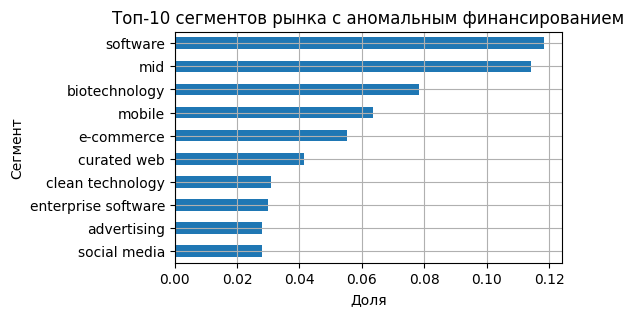

In [53]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(5, 3))

# Строим горизонтальную столбчатую диаграмму
top_market.sort_values().plot(kind='barh', 
               rot=0,
               legend=False,
               title=f'Топ-10 сегментов рынка с аномальным финансированием'
)

# Настраиваем оформление графика
plt.ylabel('Сегмент')
plt.xlabel('Доля')
plt.grid()

# Выводим график
plt.show()

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключим из датасета компании, которые мы ранее посчитали получившими аномальное финансирование.

На основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях: они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

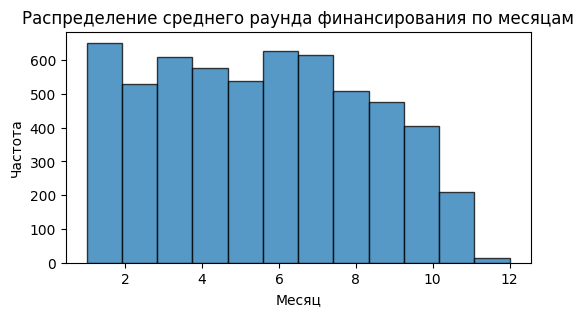

In [54]:
# Отфильтруем данные по mid_funding_at за 2014 год
df_2014 = df_filtered[df_filtered['mid_funding_at'].dt.year == 2014]

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(6, 3))

# Строим гистограмму
df_2014['mid_funding_at'].dt.month.plot(
                kind='hist',
                bins=12,
                alpha=0.75,
                edgecolor='black',
                rot=0
)

# Настраиваем оформление графика
plt.title('Распределение среднего раунда финансирования по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Частота')

# Выводим график
plt.show()

Для оценки полноты данных использованы значения столбца `mid_funding_at`, содержащего даты среднего по времени раунда финансирования. Как видно по гистрограмме, в декабре 2014 года данных существенно меньше, чем в остальные месяцы, что может свидетельствовать о неполных данных за 2014 год.

In [55]:
# Исключим из df_filtered компании, которые получили аномальное финансирование
name_iqr_out = df_iqr_out['name'].unique()
df_filtered = df_filtered[~df_filtered['name'].isin(name_iqr_out)]

In [56]:
# Отфильтруем df_filtered по компаниям, которые получили финансирование в годы, когда было зафиксировано 50 или более раундов
df_filtered['year_funding'] = df_filtered['mid_funding_at'].dt.year
grouped = df_filtered.groupby('year_funding', as_index=False)['funding_rounds'].sum()
years_50 = grouped[grouped['funding_rounds'] >= 50]['year_funding'].unique()
df_filtered = df_filtered[df_filtered['mid_funding_at'].dt.year.isin(years_50)]
print('Годы, попавшие в число актуальных (когда было зафиксировано 50 или более раундов):')
years_50

Годы, попавшие в число актуальных (когда было зафиксировано 50 или более раундов):


array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014])

### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Будем ориентироваться на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

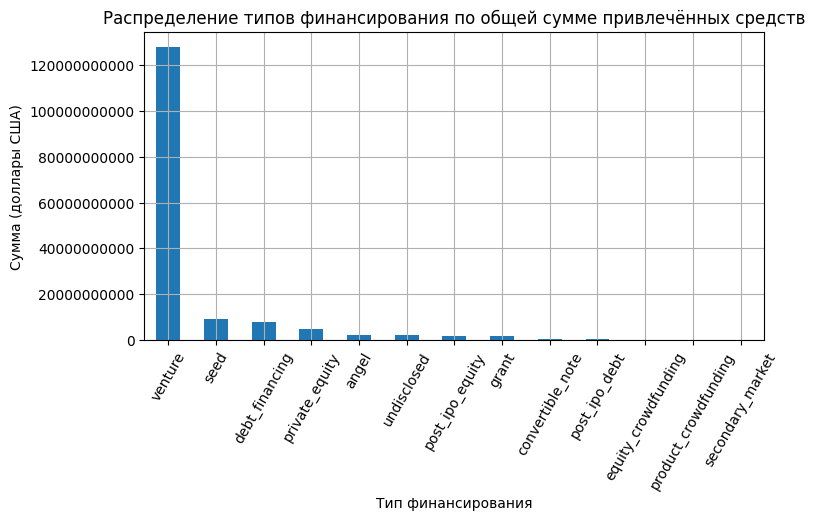

In [57]:
colums_list = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', \
               'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

# Построим график столбчатой диаграммы с разделением по типам финансирования
grouped_sum = df_filtered[colums_list].sum().sort_values(ascending=False)
grouped_sum.plot(kind='bar',
               title=f'Распределение типов финансирования по общей сумме привлечённых средств',
               xlabel='Тип финансирования',
               ylabel='Сумма (доллары США)',
               legend=False, 
               rot=60,                
               figsize=(8, 4))
# Настраиваем оформление графика
plt.grid()
plt.ticklabel_format(style='plain', axis='y')

# Выводим график
plt.show()

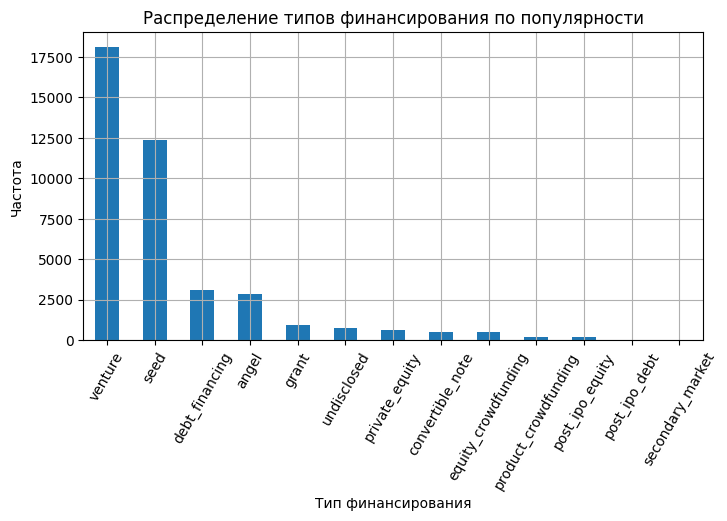

In [58]:
# Построим график столбчатой диаграммы с разделением по типам финансирования
grouped_count = df_filtered[colums_list].astype('bool').sum().sort_values(ascending=False)
grouped_count.plot(kind='bar',
               title=f'Распределение типов финансирования по популярности',
               xlabel='Тип финансирования',
               ylabel='Частота',
               legend=False, 
               rot=60,                
               figsize=(8, 4))
plt.grid()

# Выводим график
plt.show()

Наиболее популярный тип финансирования - венчурные инвестиции (`venture`) - использовался наибольшим числом компаний (18135) и привлек наибольший суммарный объем средств (более 128 млрд. долларов США). 
Гранты (`grant`) - пятый по популярности тип финансирования, который использовали 918 компаний, отличается относительно небольшим суммарным объемом финансирования - около 1.9 млрд. долларов США.
Финансирование после IPO (`post_ipo_equity`) - достаточно редко встречающийся тип финансирования, использовавшийся 163 компаниями, который характеризуется значительным для такого количества объемом предоставленных сумм - около 1.9 млрд. долларов США.

---

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

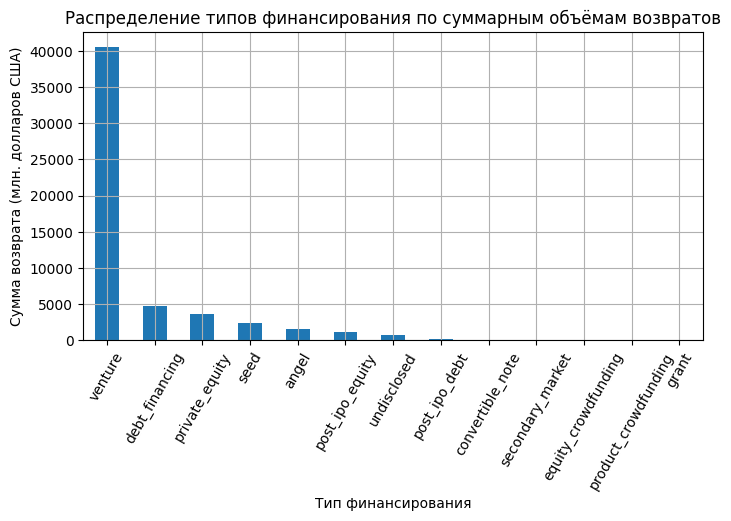

In [59]:
# Построим график столбчатой диаграммы с разделением по типам финансирования
grouped_return = df_returns[colums_list].sum().sort_values(ascending=False)
grouped_return.plot(kind='bar',
               title=f'Распределение типов финансирования по суммарным объёмам возвратов',
               xlabel='Тип финансирования',
               ylabel='Сумма возврата (млн. долларов США)',
               legend=False, 
               rot=60,                
               figsize=(8, 4))
plt.grid()

# Выводим график
plt.show()

Наибольшая сумма возвратов за весь период приходится на самый популярный тип финансирования - венчурные инвестиции (`venture`). 

### Промежуточный вывод

- Типичное значение размера общего финансирования находятся в интервале от 0.4 млн. до 10 млн. долларов США.
- Топ-3 сегмента рынка с наибольшей долей компаний, получивших аномальное финансирование: `software`, `mid` (укрупненный средний сегмент) и `biotechnology`. Из датасета исключены компании, которые получили аномальное финансирование.
- Для дальнейшего исследования в датасете оставлены данные только о компаниях, получивших финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.
- Самый популярный тип финансирования - венчурные инвестиции (`venture`), он использовался наибольшим числом компаний, привлек наибольший суммарный объем средств, а также получил наибольшую сумму возвратов.

<a class='anchor' id="link4"></a>
## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

На основе полученных данных ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [60]:
# Считаем средний объём одного раунда финансирования
df_filtered['funding_per_round'] = df['funding_total_usd'] / df['funding_rounds']

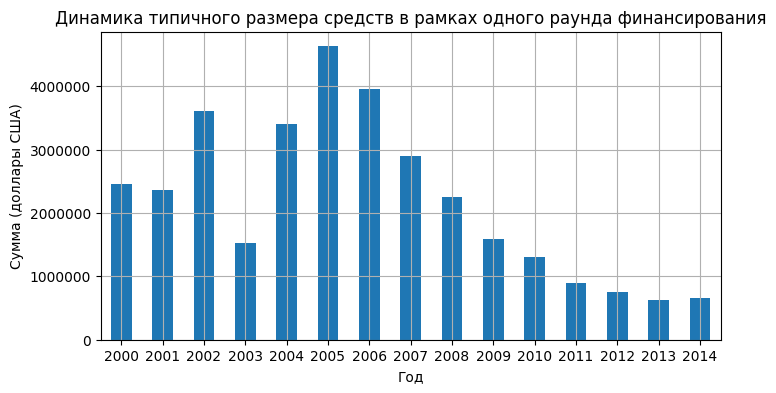

In [61]:
# Построим график столбчатой диаграммы с разделением по годам
grouped_med = df_filtered.groupby('year_funding')['funding_per_round'].median()
grouped_med.plot(kind='bar',
               title=f'Динамика типичного размера средств в рамках одного раунда финансирования',
               xlabel='Год',
               ylabel='Сумма (доллары США)',
               legend=False, 
               rot=0,                
               figsize=(8, 4))

plt.ticklabel_format(style='plain', axis='y')
plt.grid()

# Выводим график
plt.show()

Максимальный типичный размер средств, собранных в рамках одного раунда финансирования, наблюдался в 2005 году, сумма составила 4.6 млн. долларов США. После 2005 года наблюдается тренд на снижение типичного размера средств в рамках одного раунда.

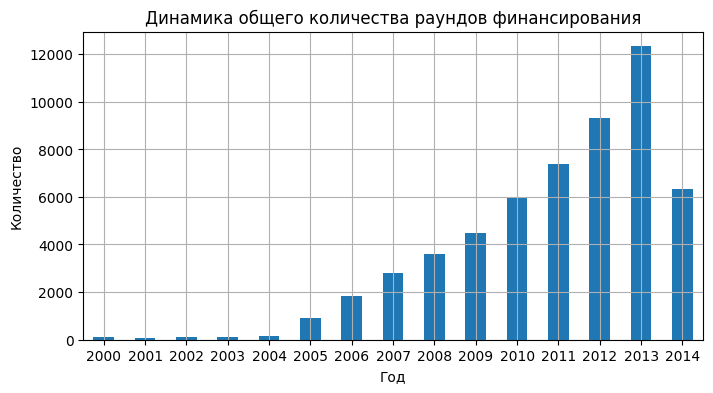

In [62]:
# Построим график столбчатой диаграммы с разделением по годам
grouped_cnt = df_filtered.groupby('year_funding')['funding_rounds'].sum()
grouped_cnt.plot(kind='bar',
               title=f'Динамика общего количества раундов финансирования',
               xlabel='Год',
               ylabel='Количество',
               legend=False, 
               rot=0,                
               figsize=(8, 4))

plt.grid()

# Выводим график
plt.show()

Активнее всего инвестиции на рынке происходили в 2013 году - было проведено около 12300 раундов финансирования.
В 2014 году наблюдалась достаточно высокая активность на рынке - около 6300 проведенных раундов финансирования, при этом типичный объем средств в рамках одного раунда был невысоким - около 650 тыс. долларов США.

Такая разнонаправленная динамика объемов и количества раундов финансирования может быть связана с тем, что до 2005 года на рынке стартапов произошло крупное негативное событие, кризис, после которого инвесторы начали диверсифицировать риски, разделяя финансирование на транши и между различными компаниями.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Будем рассматривать только массовые сегменты, а средние и нишевые исключим.

In [63]:
# Оставим только массовые сегменты
df_pivot = df_filtered[(df_filtered['market'] != 'mid') & (df_filtered['market'] != 'niche')]
pivot_funding = pd.pivot_table(df_pivot, index='market', columns='year_funding', values='funding_total_usd', aggfunc='sum', \
                              fill_value=0)
# Отфильтруем строки, в которых суммарное финансирование в 2014 году выросло по сравнению с 2013
pivot_funding = pivot_funding[(pivot_funding[2014] > pivot_funding[2013])]
pivot_funding

year_funding,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
apps,0,0,0,0,0,0,1310600,0,3050000,7219000,6123779,18374072,32601124,28868620,66237728
big data,0,0,0,0,0,0,0,7780000,2452515,597375,39233296,60369160,86413344,78698920,79232600
design,0,0,0,0,0,9300000,707000,10800000,5944302,2150144,17239976,8899967,39630692,60958836,68988512
internet,10000000,0,1100000,0,10500000,1775000,5000,4495379,23412964,38195772,36657500,36859032,28288684,69732096,117830752
manufacturing,56659312,2368582,0,4269608,3000000,61770000,163957744,147726048,173054256,422862528,244329664,561639296,522205184,393936640,416332320
medical,24000000,0,0,0,0,11090000,20250000,2100000,28812744,11566200,25590338,28540962,44039600,64469424,175236064
real estate,2500000,0,5275000,6292200,0,250000,2080000,33220000,46613100,38840212,37344608,20015128,77320856,92207656,115567360
saas,0,0,2000000,0,0,5240000,4791121,14652595,27226900,13536585,32609390,32223748,49699912,79576616,92807752
startups,0,0,0,0,0,0,0,0,5010387,460700,2111966,19654404,12358782,18080552,41501836


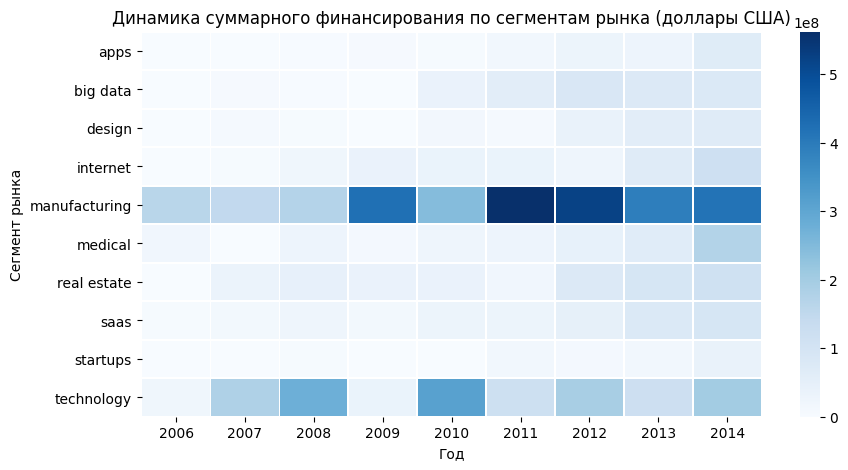

In [64]:
# Оставим в сводной таблице только те годы, в которых сведения содержатся для 70% сегментов
year_filter = pivot_funding.astype('bool').sum() * 100 / pivot_funding.shape[0]
year_list = year_filter[year_filter > 70].index.to_list()

# Построим тепловую карту
plt.figure(figsize=(10, 5))

sns.heatmap(pivot_funding[year_list],
            annot=False, 
            cmap='Blues',   
            linewidths=0.5,
            cbar=True
           )

# Добавляем заголовок и подпись по осям
plt.title('Динамика суммарного финансирования по сегментам рынка (доллары США)')
plt.xlabel('Год')
plt.ylabel('Сегмент рынка')

# Выводим график
plt.show()

В анализ включены годы, в которых зафиксировано финансирование минимум в 70% сегментов рынка, остальные годы исключены из графика как неполные, так как для них нельзя сделать выводы о рыночных трендах.

По графику можно отметить сегменты, в которых наблюдается уверенный и достаточно быстрый рост финансирования: `medical`, `real estate`, `internet`.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Наша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

In [65]:
# Считаем объем полученных средств по годам для каждого вида финансирования
total_fund = df_filtered.groupby('year_funding')[colums_list].sum()

# Считаем долю возвращенных средств в процентах. df_returns*1000000 - т.к. в датасете суммы в млн. долларов.
df_total = (df_returns * 1000000 * 100/ total_fund).replace(float('inf'), np.nan)
# Слишком большие аномальные значение (больше верхнего порога для выбросов) заменим на NaN
q1 = df_total.quantile(0.25)
q3 = df_total.quantile(0.75)
df_total = df_total.mask(df_total > (q3 + 1.5*(q3-q1)), np.nan) 
# Учитываем только те годы, которые остались после исключения аномальных финансирований
df_total = df_total.dropna(how='all')
df_total

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,99.86,16.99,NaN,69.70,NaN,61.86,26.70,0.00,NaN,27.11,NaN,2.59,NaN
2001,107.96,11.15,NaN,58.75,0.67,NaN,118.00,0.00,NaN,NaN,NaN,NaN,NaN
2002,62.97,68.28,NaN,60.89,NaN,22.34,113.67,NaN,20.13,113.33,NaN,NaN,NaN
2003,53.77,63.38,NaN,91.44,NaN,103.81,60.57,0.00,NaN,NaN,NaN,NaN,NaN
2004,56.25,84.24,NaN,56.67,NaN,47.02,83.35,0.00,NaN,NaN,NaN,NaN,NaN
2005,77.76,54.89,NaN,NaN,NaN,34.50,50.99,0.00,48.00,73.19,NaN,NaN,NaN
2006,96.17,34.51,NaN,80.34,NaN,82.91,67.60,0.00,94.79,NaN,NaN,NaN,NaN
2007,36.82,29.80,NaN,50.50,NaN,60.25,82.58,0.00,59.01,203.00,NaN,NaN,NaN
2008,30.59,19.16,NaN,34.89,6.98,93.07,41.42,0.00,67.99,234.11,NaN,NaN,0.00


Построим график, на котором отобразим нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделаем вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

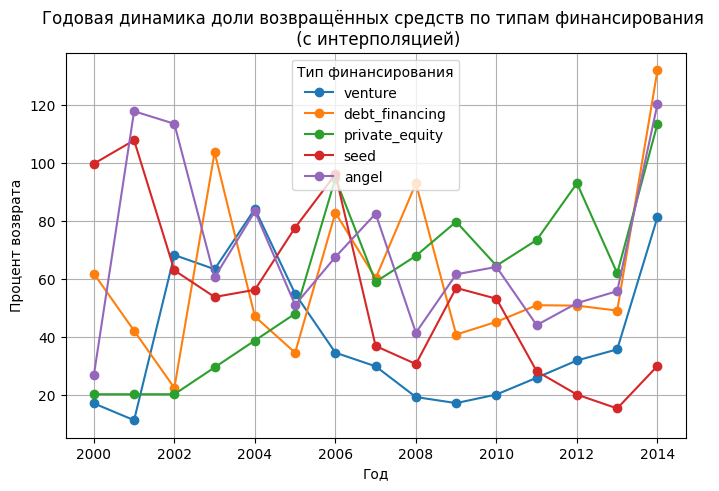

In [66]:
# Строим график линейной диаграммы
type_list = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
df_total_inter = df_total[type_list].interpolate(method='index', limit_direction='both')

df_total_inter.plot(kind='line',
               marker='o',                                                                
               title=f'Годовая динамика доли возвращённых средств по типам финансирования \n (с интерполяцией)',
               ylabel='Процент возврата',
               xlabel='Год',
               figsize=(8, 5))

plt.legend(title='Тип финансирования')
plt.grid()

# Выводим график
plt.show()

Наиболее устойчивый рост нормированного значения возврата средств наблюдается для венчурных инвестиций (`venture`) и инвестиций в виде прямых (частных) вложений (`private_equity`).

При построении графика выполнена линейная интерполяция пропусков для лучшей визуализации тренда.

### Промежуточный вывод

- Типичный размер средств, собранных в рамках одного раунда финансирования, достиг максимума в 2005 году, его сумма составила 4.6 млн. долларов США. После 2005 года наблюдается снижение среднего объёма одного раунда финансирования.
- С 2005 года отмечается рост общего количества раундов финансирования, пик активности пришелся на 2013 год, когда было проведено около 12300 раундов финансирования.
- Сегменты с уверенным и достаточно быстрым ростом финансирования - `medical`, `real estate`, `internet`.
- Для венчурных инвестиций и инвестиций в виде прямых (частных) вложений наблюдается устойчивый рост нормированного значения возврата средств.

<a class='anchor' id="link5"></a>
## Шаг 5. Итоговый вывод и рекомендации

### Общий обзор проделанной работы

В ходе исследования были проанализированы данные о финансировании стартапов с 2000 по 2014 год. Данные содержали информацию о компаниях и состоявшемся финансировании, а также  об объёмах возвратов по годам и типам финансирования. В ходе проверки полноты данных выявлено, что практически отсутствуют данные за декабрь 2014 года. С помощью метода IQR были выявлены компании, которые получили аномальное финансирование, эти сведения были исключены из дальнейшего анализа. Также в датасете были оставлены данные только о компаниях, которые получали финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

### Основые результаты исследования

- Самым популярным является единичное финансирование, оно характерно для 58.9% компаний, при этом объем привлеченных средств для такого типа составляет менее трети от общей суммы - 30.6%. Наибольшая доля общего объёма привлечённых средств приходится на финансирование со сроком более 1 года - 61.9%, такой тип используется для 30.1% компаний.
- Большая часть компаний занята в массовых сегментах, их доля составляет 87.8%, в нишевых сегментах сосредоточено 2.2% компаний. При этом доля различных массовых сегментов составляет всего 12.2%, в то время как в нишевых - 73.3% отраслей рынка. Это свидетельствует о высокой конкуренции в массовых сегментах и недофинансированности в нишевых.
- Самый массовый сегмент рынка - `software`, к нему относится около 4800 компаний.
- Типичный размер общего финансирования составляет 2.1 млн. долларов США и находится в диапазоне от 0.4 млн. до 10 млн. долларов США.
- Чаще всего используются венчурные инвестиции (18 тыс. компаний), которые привлекли наибольший суммарный объем средств (более 128 млрд. долларов США). При этом наибольшая сумма возвратов за весь период также приходится на этот тип финансирования (41 млрд. долларов США).
- Начиная с 2005 года выявлен тренд на одновременное снижение типичного размера средств в рамках одного раунда финансирования и увеличение числа раундов. 
- Уверенный и достаточно быстрый рост финансирования наблюдается для следующих сегментов рынка: `medical`, `real estate`, `internet`.
- Для венчурных инвестиций и инвестиций в виде прямых (частных) вложений отмечается рост доли возвращенных средств.

### Рекомендации на основе анализа данных

В качестве отраслей, привлекательных для инвестирования, можно рассмотреть растущие массовые сегменты рынка `medical`, `real estate`, `internet`.
Для диверсификации рисков рекомендуется рассмотреть венчурное инвестирование или прямые вложения со сроком более 1 года и несколькими раундами финансирования.